# CommerceLens — Layer 1: SQL Analytics

**Anchor question:** *Where is revenue concentrated, and which operational factors (delivery time, freight cost, product category, region) drive customer satisfaction and repeat purchases?*

This notebook answers the first half — **where revenue is concentrated** — using real SQL that DuckDB runs straight against the raw Olist CSVs. Every query is in `sql/`, and this notebook only loads and runs those files.

| Query file | Question |
|---|---|
| `00_base_views.sql` | Cleaned, joined views (items + orders + reviews + customers) |
| `01_order_status.sql`, `02_order_funnel.sql` | How many orders make it to the customer? |
| `03`–`05_*.sql` | Pareto: how concentrated is revenue by category, seller and state? |
| `06_monthly_trend.sql` | How did revenue grow over time? |
| `07_order_frequency.sql` | How often do customers come back? |
| `08`–`09_rfm_*.sql` | RFM segmentation (Recency × Monetary) |
| `10_kpis.sql` | Headline KPIs |

**Definitions:** *Revenue* = item price (GMV excluding freight) on **delivered** orders. *Customer* = `customer_unique_id`, because Olist creates a new `customer_id` for every order.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

from src import db

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)

# Chart style: one accent hue, muted axes, no chart junk.
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8983"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.titleweight": "bold", "axes.titlesize": 12,
})
brl = mtick.FuncFormatter(lambda x, _: f"R${x/1e6:,.1f}M" if abs(x) >= 1e6 else f"R${x/1e3:,.0f}k")

con = db.connect()  # registers the 9 CSVs as views + runs sql/00_base_views.sql
print("Views:", sorted(r[0] for r in con.sql("SELECT view_name FROM duckdb_views() WHERE NOT internal").fetchall()))

Views: ['category_translation', 'customers', 'geolocation', 'order_items', 'order_items_enriched', 'order_reviews_latest', 'orders', 'orders_enriched', 'payments', 'products', 'reviews', 'sellers']


## 1. Headline KPIs

In [2]:
kpis = db.query(con, "10_kpis.sql")
kpis.T.rename(columns={0: "value"})

,value
total_orders_all_statuses,99441
delivered_orders,96478
revenue,"13,221,498.11"
avg_order_value,137.04
customers,93358
repeat_customer_pct,3.00
avg_review_score,4.16
late_delivery_pct,6.77
first_order_date,2016-09-04 00:00:00
last_order_date,2018-10-17 00:00:00


## 2. Order funnel

Final status alone hides where orders drop out, so `02_order_funnel.sql` builds the funnel from the lifecycle **timestamps** (approved → handed to carrier → delivered).

In [3]:
status = db.query(con, "01_order_status.sql")
status

,order_status,orders,pct_of_orders
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


,stage_order,stage,orders,pct_of_purchased,pct_of_previous_stage
0,1,Purchased,99441,100.00,NaN
1,2,Payment approved,99281,99.84,99.84
2,3,Handed to carrier,97658,98.21,98.37
3,4,Delivered to customer,96470,97.01,98.78


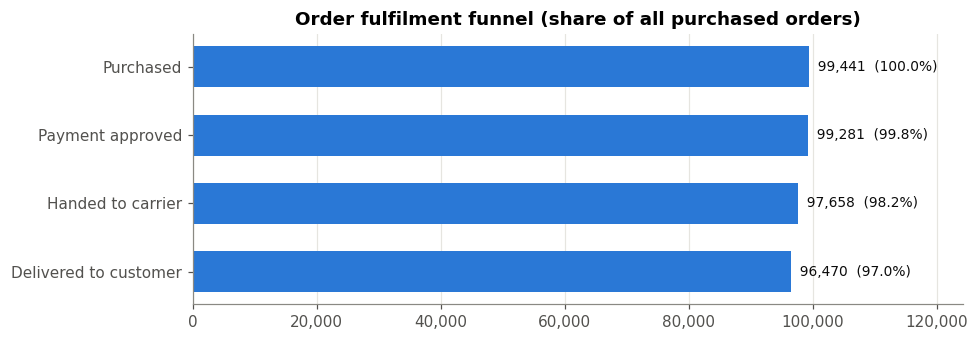

In [4]:
funnel = db.query(con, "02_order_funnel.sql")
display(funnel)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(funnel["stage"], funnel["orders"], color=BLUE, height=0.6)
ax.invert_yaxis()
for y, (n, p) in enumerate(zip(funnel["orders"], funnel["pct_of_purchased"])):
    ax.text(n, y, f"  {n:,}  ({p:.1f}%)", va="center", fontsize=9, color="#0b0b0b")
ax.set_xlim(0, funnel["orders"].max() * 1.25)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", visible=False)
ax.set_title("Order fulfilment funnel (share of all purchased orders)")
plt.tight_layout(); plt.show()

## 3. Revenue concentration (Pareto)

Every Pareto query uses a running window `SUM(...) OVER (ORDER BY revenue DESC ROWS UNBOUNDED PRECEDING)` to get the cumulative share.

### 3a. By product category

In [5]:
cat = db.query(con, "03_pareto_category.sql")
display(cat.head(15))

n_cat_80 = int((cat["cumulative_pct"] < 80).sum() + 1)
top10_cat_share = cat.head(10)["pct_of_revenue"].sum()
print(f"{n_cat_80} of {len(cat)} categories ({100*n_cat_80/len(cat):.0f}%) produce 80% of revenue; "
      f"the top 10 categories produce {top10_cat_share:.1f}%.")

,rank,category,revenue,orders,pct_of_revenue,cumulative_pct,cumulative_pct_of_categories
0,1,health_beauty,"1,233,131.72",8647,9.33,9.33,1.35
1,2,watches_gifts,"1,166,176.98",5495,8.82,18.15,2.70
2,3,bed_bath_table,"1,023,434.76",9272,7.74,25.89,4.05
3,4,sports_leisure,"954,852.55",7530,7.22,33.11,5.41
4,5,computers_accessories,"888,724.61",6530,6.72,39.83,6.76
5,6,furniture_decor,"711,927.69",6307,5.38,45.22,8.11
6,7,housewares,"615,628.69",5743,4.66,49.87,9.46
7,8,cool_stuff,"610,204.10",3559,4.62,54.49,10.81
8,9,auto,"578,966.65",3810,4.38,58.87,12.16
9,10,toys,"471,286.48",3804,3.56,62.43,13.51


18 of 74 categories (24%) produce 80% of revenue; the top 10 categories produce 62.4%.


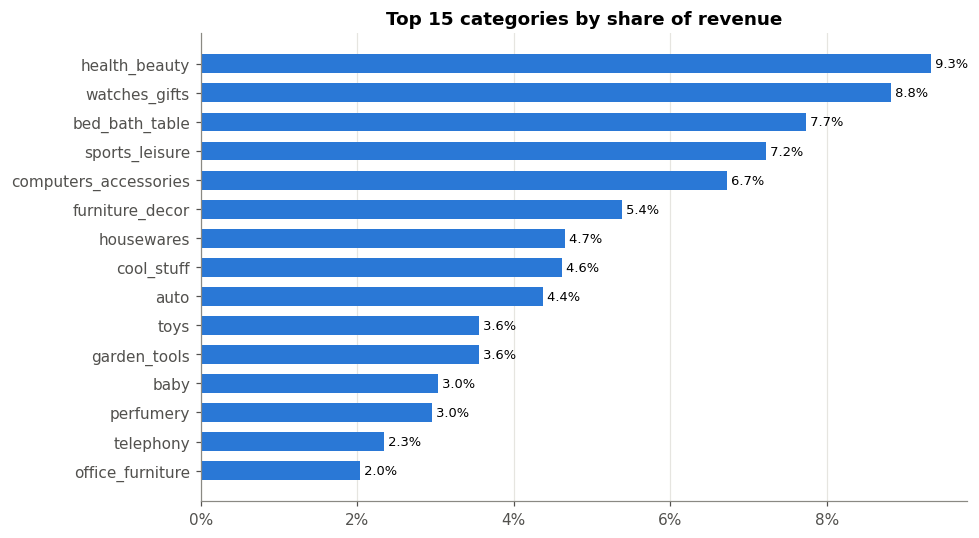

In [6]:
top = cat.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["category"], top["pct_of_revenue"], color=BLUE, height=0.65)
for y, v in enumerate(top["pct_of_revenue"]):
    ax.text(v, y, f" {v:.1f}%", va="center", fontsize=8.5)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
ax.set_title("Top 15 categories by share of revenue")
plt.tight_layout(); plt.show()

### 3b. By seller

In [7]:
sellers = db.query(con, "04_pareto_seller.sql")
display(sellers.head(10))

top20_seller_share = sellers.loc[sellers["cumulative_pct_of_sellers"] <= 20, "revenue"].sum() / sellers["revenue"].sum() * 100
n_seller_80 = int((sellers["cumulative_pct"] < 80).sum() + 1)
print(f"{len(sellers):,} sellers. The top 20% of sellers produce {top20_seller_share:.1f}% of revenue; "
      f"{n_seller_80:,} sellers ({100*n_seller_80/len(sellers):.1f}%) cover 80% of revenue.")

,rank,seller_id,seller_state,revenue,orders,pct_of_revenue,cumulative_pct,cumulative_pct_of_sellers
0,1,4869f7a5dfa277a7dca6462dcf3b52b2,SP,"226,987.93",1124,1.72,1.72,0.03
1,2,53243585a1d6dc2643021fd1853d8905,BA,"217,940.44",348,1.65,3.37,0.07
2,3,4a3ca9315b744ce9f8e9374361493884,SP,"196,882.12",1772,1.49,4.85,0.10
3,4,fa1c13f2614d7b5c4749cbc52fecda94,SP,"190,917.14",578,1.44,6.30,0.13
4,5,7c67e1448b00f6e969d365cea6b010ab,SP,"186,570.05",973,1.41,7.71,0.17
5,6,7e93a43ef30c4f03f38b393420bc753a,SP,"165,981.49",319,1.26,8.96,0.20
6,7,da8622b14eb17ae2831f4ac5b9dab84a,SP,"159,816.87",1311,1.21,10.17,0.24
7,8,7a67c85e85bb2ce8582c35f2203ad736,SP,"139,658.69",1145,1.06,11.23,0.27
8,9,1025f0e2d44d7041d6cf58b6550e0bfa,SP,"138,208.56",910,1.05,12.28,0.30
9,10,955fee9216a65b617aa5c0531780ce60,SP,"131,836.71",1261,1.00,13.27,0.34


2,970 sellers. The top 20% of sellers produce 82.3% of revenue; 533 sellers (17.9%) cover 80% of revenue.


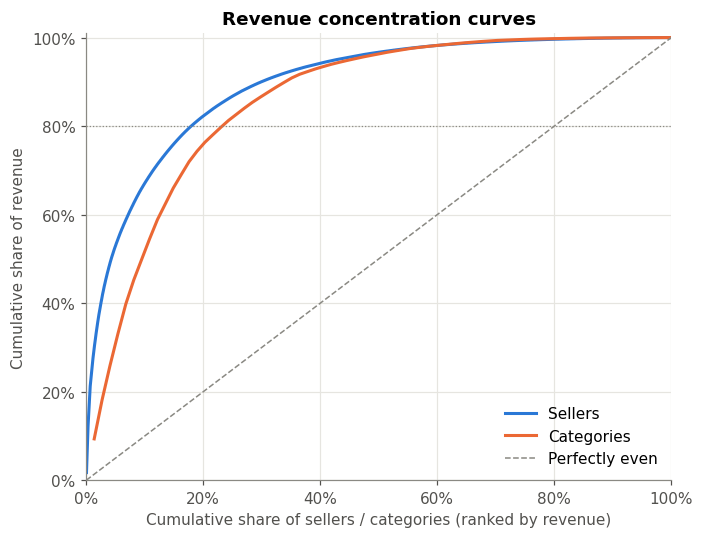

In [8]:
# Lorenz-style concentration curves on one shared scale: % of entities vs % of revenue.
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(sellers["cumulative_pct_of_sellers"], sellers["cumulative_pct"], color=BLUE, lw=2, label="Sellers")
ax.plot(cat["cumulative_pct_of_categories"], cat["cumulative_pct"], color=ORANGE, lw=2, label="Categories")
ax.plot([0, 100], [0, 100], color=GREY, lw=1, ls="--", label="Perfectly even")
ax.axhline(80, color=GREY, lw=0.8, ls=":")
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Cumulative share of sellers / categories (ranked by revenue)")
ax.set_ylabel("Cumulative share of revenue")
ax.set_xlim(0, 100); ax.set_ylim(0, 101)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Revenue concentration curves")
plt.tight_layout(); plt.show()

### 3c. By customer state

In [9]:
states = db.query(con, "05_revenue_by_state.sql")
display(states.head(10))

top3 = states.head(3)
print(f"Top 3 states ({', '.join(top3['customer_state'])}) = {top3['pct_of_revenue'].sum():.1f}% of revenue; "
      f"{states.iloc[0]['customer_state']} alone = {states.iloc[0]['pct_of_revenue']:.1f}%.")

,rank,customer_state,orders,customers,revenue,avg_order_value,pct_of_revenue,cumulative_pct
0,1,SP,40501,39156,"5,067,633.16",125.12,38.33,38.33
1,2,RJ,12350,11917,"1,759,651.13",142.48,13.31,51.64
2,3,MG,11354,11001,"1,552,481.83",136.73,11.74,63.38
3,4,RS,5345,5168,"728,897.47",136.37,5.51,68.89
4,5,PR,4923,4769,"666,063.51",135.30,5.04,73.93
5,6,SC,3546,3449,"507,012.13",142.98,3.83,77.77
6,7,BA,3256,3158,"493,584.14",151.59,3.73,81.50
7,8,DF,2080,2019,"296,498.41",142.55,2.24,83.74
8,9,GO,1957,1895,"282,836.70",144.53,2.14,85.88
9,10,ES,1995,1928,"268,643.45",134.66,2.03,87.91


Top 3 states (SP, RJ, MG) = 63.4% of revenue; SP alone = 38.3%.


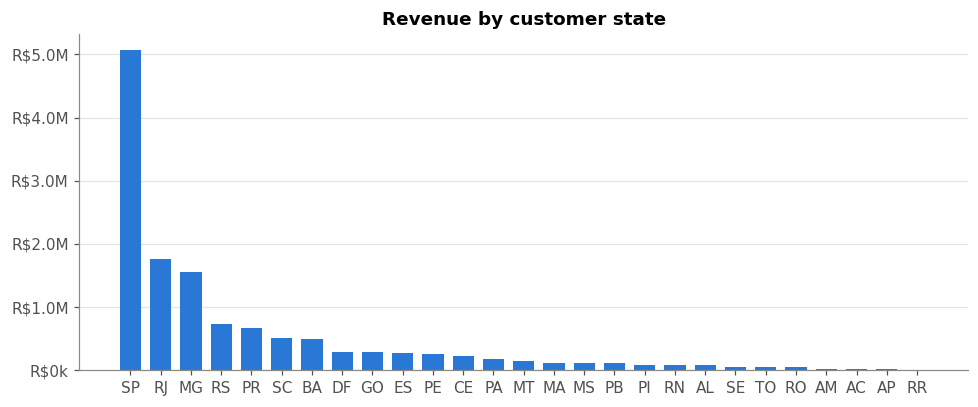

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(states["customer_state"], states["revenue"], color=BLUE, width=0.7)
ax.yaxis.set_major_formatter(brl)
ax.grid(axis="x", visible=False)
ax.set_title("Revenue by customer state")
plt.tight_layout(); plt.show()

## 4. Monthly revenue trend

`06_monthly_trend.sql` uses `LAG()` for month-over-month growth. Months with fewer than 500 delivered orders are sparse dataset edges (late 2016, the end of 2018) and are flagged `is_partial_edge`, so they are left out of the growth read.

In [11]:
monthly = db.query(con, "06_monthly_trend.sql")
display(monthly)

full = monthly[~monthly["is_partial_edge"]]
y2017 = full[pd.to_datetime(full["month"]).dt.year == 2017]["revenue"].sum()
jan_aug = lambda y: full[(pd.to_datetime(full["month"]).dt.year == y) & (pd.to_datetime(full["month"]).dt.month <= 8)]["revenue"].sum()
print(f"Full months analysed: {pd.Timestamp(full['month'].min()).strftime('%Y-%m')} to {pd.Timestamp(full['month'].max()).strftime('%Y-%m')} ({len(full)} months)")
print(f"Peak month: {pd.Timestamp(full.loc[full['revenue'].idxmax(), 'month']).strftime('%Y-%m')} (R${full['revenue'].max():,.0f})")
print(f"Jan-Aug revenue growth 2018 vs 2017: {100*(jan_aug(2018)/jan_aug(2017)-1):.1f}%")

,month,orders,revenue,avg_order_value,revenue_mom_pct,is_partial_edge
0,2016-09-01,1,134.97,134.97,NaN,True
1,2016-10-01,265,"40,325.11",152.17,NaN,True
2,2016-12-01,1,10.90,10.90,NaN,True
3,2017-01-01,750,"111,798.36",149.06,NaN,False
4,2017-02-01,1653,"234,223.40",141.70,109.51,False
5,2017-03-01,2546,"359,198.85",141.08,53.36,False
6,2017-04-01,2303,"340,669.68",147.92,-5.16,False
7,2017-05-01,3546,"489,338.25",138.00,43.64,False
8,2017-06-01,3135,"421,923.37",134.58,-13.78,False
9,2017-07-01,3872,"481,604.52",124.38,14.15,False


Full months analysed: 2017-01 to 2018-08 (20 months)
Peak month: 2017-11 (R$987,765)
Jan-Aug revenue growth 2018 vs 2017: 141.1%


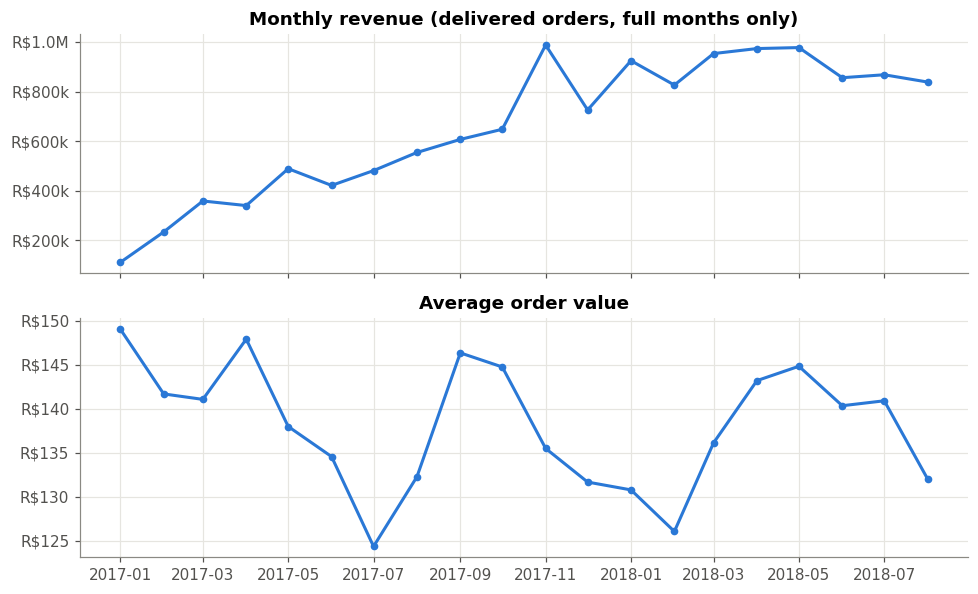

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
m = pd.to_datetime(full["month"])
axes[0].plot(m, full["revenue"], color=BLUE, lw=2, marker="o", ms=4)
axes[0].yaxis.set_major_formatter(brl)
axes[0].set_title("Monthly revenue (delivered orders, full months only)")
axes[1].plot(m, full["avg_order_value"], color=BLUE, lw=2, marker="o", ms=4)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
axes[1].set_title("Average order value")
plt.tight_layout(); plt.show()

## 5. Purchase frequency: the one-time-buyer skew

This is the most important structural fact in the dataset. It is why RFM below segments on **Recency × Monetary**, and why Layer 3 has to check whether repeat purchase is predictable at all.

In [13]:
freq = db.query(con, "07_order_frequency.sql")
display(freq)
one_time_pct = freq.loc[freq["orders_per_customer"] == "1", "pct_of_customers"].iloc[0]
print(f"{one_time_pct:.1f}% of customers placed exactly one delivered order.")

,orders_per_customer,customers,pct_of_customers
0,1,90557,97.00
1,2,2573,2.76
2,3,181,0.19
3,4+,47,0.05


97.0% of customers placed exactly one delivered order.


## 6. RFM segmentation

`08_rfm_customers.sql` scores each `customer_unique_id` into Recency and Monetary quintiles with `NTILE(5)`. **Frequency is not scored.** With most customers on exactly one order, a frequency quintile would just split ties at random, so it is kept only as a repeat-buyer flag.

| Segment | Rule |
|---|---|
| Champions | R ≥ 4 and M ≥ 4 |
| Recent, low spend | R ≥ 4, M ≤ 3 |
| Potential loyalists | R = 3, M ≥ 4 |
| Needs attention | R = 3, M ≤ 3 |
| At risk, high value | R ≤ 2, M ≥ 4 |
| Hibernating | R ≤ 2, M ≤ 3 |

In [14]:
db.run_script(con, "08_rfm_customers.sql")
segments = db.query(con, "09_rfm_segments.sql")
segments

,segment,customers,pct_of_customers,revenue,pct_of_revenue,avg_monetary,median_recency_days,pct_repeat_buyers
0,Champions,15414,16.51,"4,173,789.59",31.57,270.78,94.00,6.05
1,"At risk, high value",14517,15.55,"4,044,943.95",30.59,278.63,380.00,5.00
2,Potential loyalists,7411,7.94,"1,876,116.63",14.19,253.15,219.00,6.44
3,Hibernating,22827,24.45,"1,277,155.15",9.66,55.95,385.00,1.18
4,"Recent, low spend",21928,23.49,"1,222,626.29",9.25,55.76,91.00,1.23
5,Needs attention,11261,12.06,"626,866.50",4.74,55.67,220.00,1.11


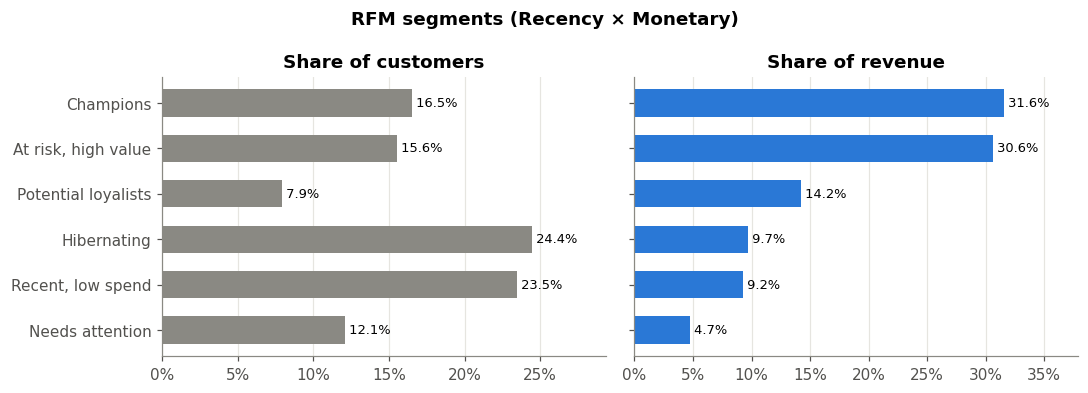

In [15]:
s = segments.sort_values("pct_of_revenue")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
axes[0].barh(s["segment"], s["pct_of_customers"], color=GREY, height=0.6)
axes[0].set_title("Share of customers")
axes[1].barh(s["segment"], s["pct_of_revenue"], color=BLUE, height=0.6)
axes[1].set_title("Share of revenue")
for ax, col in zip(axes, ["pct_of_customers", "pct_of_revenue"]):
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.grid(axis="y", visible=False)
    for y, v in enumerate(s[col]):
        ax.text(v, y, f" {v:.1f}%", va="center", fontsize=8.5)
    ax.set_xlim(0, s[col].max() * 1.2)
plt.suptitle("RFM segments (Recency × Monetary)", fontweight="bold")
plt.tight_layout(); plt.show()

## 7. Layer 1 summary

Every number below is computed by the cells above, and none are typed in by hand. Layer 2 (`02_insights.ipynb`) picks up the second half of the anchor question: **which operational factors drive satisfaction and repeat purchase.**

In [16]:
k = kpis.iloc[0]
champ = segments.set_index("segment").loc["Champions"]
delivered_pct = funnel.loc[funnel["stage"] == "Delivered to customer", "pct_of_purchased"].iloc[0]
print(f"- {k.delivered_orders:,} delivered orders, R${k.revenue:,.0f} revenue, AOV R${k.avg_order_value:,.2f}, "
      f"{k.customers:,} unique customers ({pd.Timestamp(k.first_order_date):%Y-%m-%d} to {pd.Timestamp(k.last_order_date):%Y-%m-%d}).")
print(f"- Funnel: {delivered_pct:.1f}% of purchased orders reach the customer.")
print(f"- Category concentration: {n_cat_80} of {len(cat)} categories = 80% of revenue; top 10 = {top10_cat_share:.1f}%.")
print(f"- Seller concentration: top 20% of sellers = {top20_seller_share:.1f}% of revenue.")
print(f"- Geography: {', '.join(top3['customer_state'])} = {top3['pct_of_revenue'].sum():.1f}% of revenue.")
print(f"- Retention: {one_time_pct:.1f}% of customers bought once; repeat-customer rate {k.repeat_customer_pct:.2f}%.")
print(f"- RFM: Champions are {champ.pct_of_customers:.1f}% of customers but {champ.pct_of_revenue:.1f}% of revenue.")

- 96,478 delivered orders, R$13,221,498 revenue, AOV R$137.04, 93,358 unique customers (2016-09-04 to 2018-10-17).
- Funnel: 97.0% of purchased orders reach the customer.
- Category concentration: 18 of 74 categories = 80% of revenue; top 10 = 62.4%.
- Seller concentration: top 20% of sellers = 82.3% of revenue.
- Geography: SP, RJ, MG = 63.4% of revenue.
- Retention: 97.0% of customers bought once; repeat-customer rate 3.00%.
- RFM: Champions are 16.5% of customers but 31.6% of revenue.
